In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import seaborn as sns
import matplotlib as plt

#**1. Data understanding and observations**

In [20]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [21]:
train.shape, test.shape

((54808, 14), (23490, 13))

In [22]:
train.dtypes

,0
employee_id,int64
department,object
region,object
education,object
gender,object
recruitment_channel,object
no_of_trainings,int64
age,int64
previous_year_rating,float64
length_of_service,int64


In [23]:
# To check the column details and Non-NULL values
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [24]:
train.isna().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


In [25]:
train.isna().sum()[train.isna().sum() > 0]

,0
education,2409
previous_year_rating,4124


In [26]:
# To check Class distribution and observed the target data is highly Imbalanced

train['is_promoted'].value_counts()

,count
is_promoted,
0,50140
1,4668


# **2. Exploratory Data Analysis**

In [27]:
train['is_promoted'].value_counts(normalize=True) * 100

,proportion
is_promoted,
0,91.482995
1,8.517005


[Text(0, 0, '50140'), Text(0, 0, '4668')]

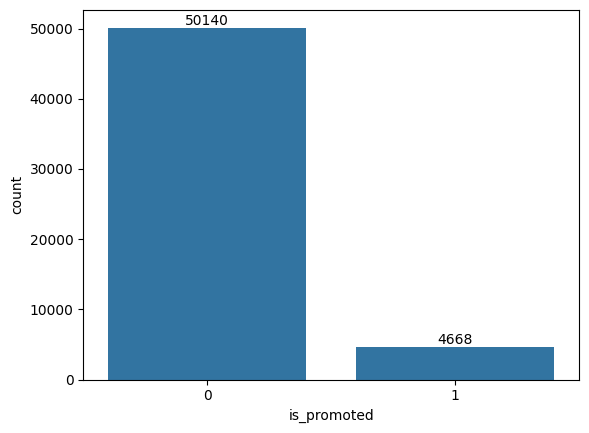

In [28]:
ax = sns.countplot(x = 'is_promoted', data = train)
ax.bar_label(ax.containers[0])

In [29]:

train.groupby('KPIs_met >80%')['is_promoted'].mean()



,is_promoted
KPIs_met >80%,
0,0.039587
1,0.169094


In [30]:

train.groupby('awards_won?')['is_promoted'].mean()


,is_promoted
awards_won?,
0,0.076749
1,0.440157


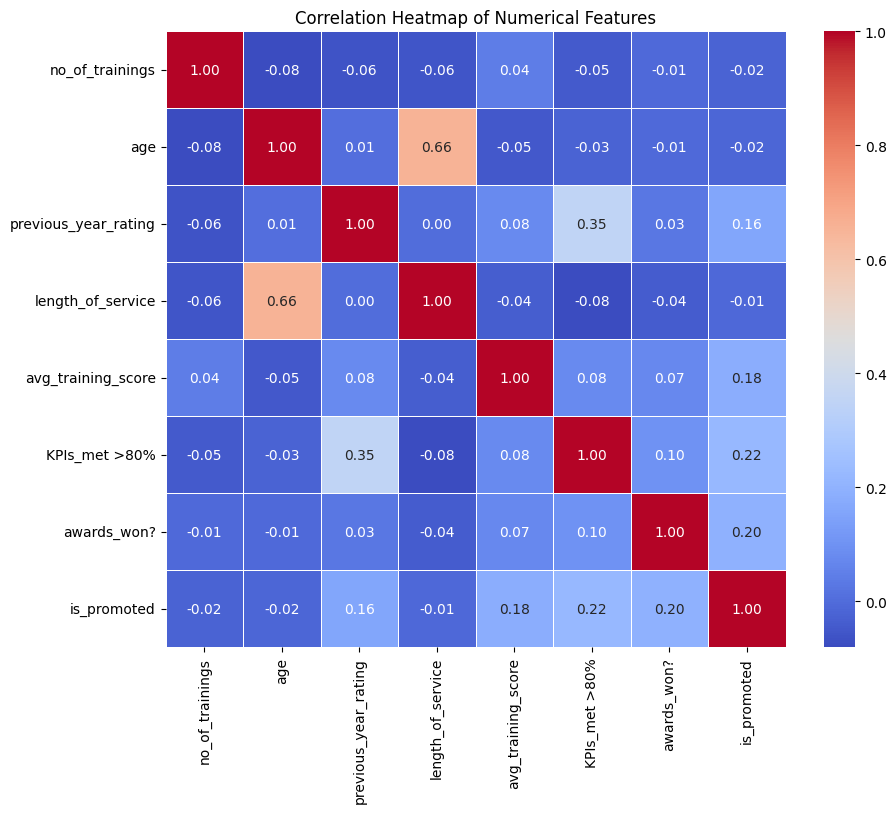

In [31]:
import matplotlib.pyplot as plt

# Numerical columns
num_cols = [
    'no_of_trainings',
    'age',
    'previous_year_rating',
    'length_of_service',
    'avg_training_score',
    'KPIs_met >80%',
    'awards_won?',
    'is_promoted'
]

num_df = train[num_cols]

corr_matrix = num_df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

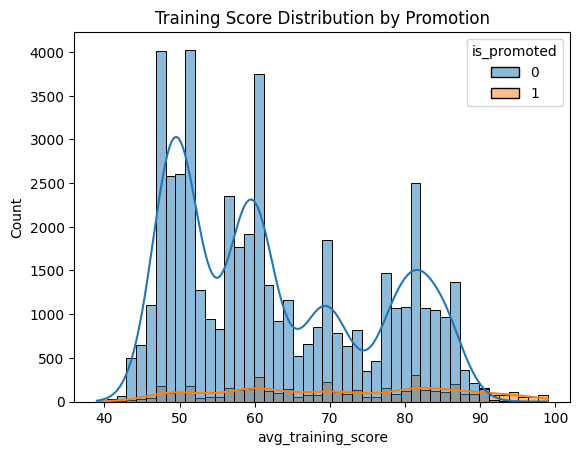

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=train, x='avg_training_score', hue='is_promoted', kde=True)

plt.title('Training Score Distribution by Promotion')

plt.show()

In [33]:
test_ids = test['employee_id']

train.drop('employee_id', axis=1, inplace=True)
test.drop('employee_id', axis=1, inplace=True)

# **3. Data Cleansing & Feature engineering**

In [34]:

# Identify row level duplicates and remove it
total_rows_before = len(train)
print("Total rows before deduplication:", total_rows_before)

Total rows before deduplication: 54808


In [35]:
duplicate_count = train.duplicated().sum()
print("Number of exact duplicate rows:", duplicate_count)

Number of exact duplicate rows: 118


In [36]:
train[train.duplicated(keep=False)].head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
123,Operations,region_22,Bachelor's,f,sourcing,1,27,NaN,1,1,0,58,0
327,Analytics,region_25,Bachelor's,m,sourcing,1,32,3.0,6,1,0,86,0
899,Legal,region_2,Bachelor's,m,sourcing,1,30,NaN,1,0,0,63,0
924,Sales & Marketing,region_29,Bachelor's,m,other,1,33,1.0,4,0,0,50,0
974,Analytics,region_22,Bachelor's,m,other,1,28,NaN,1,1,0,86,1


In [37]:
train = train.drop_duplicates().reset_index(drop=True)

In [38]:
total_rows_after = len(train)
print("Total rows after deduplication:", total_rows_after)
print("Number of rows removed:", total_rows_before - total_rows_after)

Total rows after deduplication: 54690
Number of rows removed: 118


In [39]:
# Fill missing education with mode
for df in [train, test]:
    df['education'] = df['education'].fillna(train['education'].mode()[0])

# Fill missing previous_year_rating with 0
for df in [train, test]:
    df['previous_year_rating'] = df['previous_year_rating'].fillna(0)


In [40]:
binary_cols = ['KPIs_met >80%', 'awards_won?']
for df in [train, test]:
    df[binary_cols] = df[binary_cols].astype(int)
    df['avg_training_score'] = df['avg_training_score'].clip(40, 100)

for df in [train, test]:
    df['training_efficiency'] = df['avg_training_score'] / (df['length_of_service'] + 1)
    df['performance_index'] = df['avg_training_score'] * (df['KPIs_met >80%'] + 1) * (df['awards_won?'] + 1)

    df['kpi_per_training'] = df['KPIs_met >80%'] / (df['no_of_trainings'] + 1)
    df['awards_per_service'] = df['awards_won?'] / (df['length_of_service'] + 1)
    df['score_times_awards'] = df['avg_training_score'] * (df['awards_won?'] + 1)
    df['score_times_kpi'] = df['avg_training_score'] * (df['KPIs_met >80%'] + 1)


# Features & target

target = 'is_promoted'
categorical_features = ['department', 'region', 'education', 'gender', 'recruitment_channel']
numerical_features = [
    'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service',
    'avg_training_score', 'KPIs_met >80%', 'awards_won?',
    'training_efficiency', 'performance_index', 'kpi_per_training',
    'awards_per_service', 'score_times_awards', 'score_times_kpi'
]

X = train.drop(target, axis=1)
y = train[target]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


# **4. Preprocessing and Model Building**


In [41]:

numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median'))])
categorical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                 ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])


# SMOTE: oversample minority to 60% of majority
smote = SMOTE(sampling_strategy=0.6, random_state=42)

xgb = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1
)

pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', xgb)
])


# Train model

pipeline.fit(X_train, y_train)

# Threshold tuning

val_probs = pipeline.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.1, 0.91, 0.005)

best_f1 = 0
best_threshold = 0
for t in thresholds:
    preds = (val_probs >= t).astype(int)
    score = f1_score(y_val, preds)
    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Validation F1:", best_f1)


Best Threshold: 0.2550000000000001
Validation F1: 0.5372279495990836


# **5. Evaluate Test data and Capture Score**

In [42]:
test_probs = pipeline.predict_proba(test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)

submission = pd.DataFrame({'employee_id': test_ids, 'is_promoted': test_preds})
submission.to_csv('submission.csv', index=False)
print("Test predictions saved to submission.csv")

Test predictions saved to submission.csv


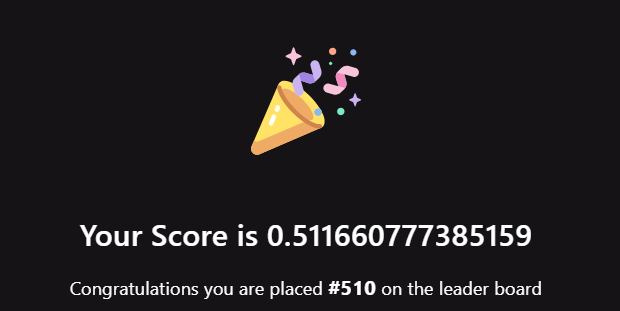

## **Model Storage**

In [43]:
import joblib

artifact = {
    "model": pipeline,
    "threshold": best_threshold
}

joblib.dump(artifact, "Emp_Promotion_model.pkl")

['Emp_Promotion_model.pkl']

## **UI Development using Streamlit**

In [44]:
%%writefile Web_Interface_View.py
import streamlit as st
import pandas as pd
import joblib

# --------------------------------------------------
# App Title
# --------------------------------------------------
st.title("Employee Promotion Prediction")

# --------------------------------------------------
# Load Training Data
# --------------------------------------------------
df = pd.read_csv("train.csv")

# --------------------------------------------------
# Load Model
# --------------------------------------------------
artifact = joblib.load("Emp_Promotion_model.pkl")
model = artifact["model"]
THRESHOLD = artifact["threshold"]

# --------------------------------------------------
# UI Inputs
# --------------------------------------------------

department = st.selectbox(
    "Department",
    pd.unique(df['department'])
)

region = st.selectbox(
    "Region",
    pd.unique(df['region'])
)

education = st.selectbox(
    "Education",
    pd.unique(df['education'].dropna())
)

gender = st.selectbox(
    "Gender",
    pd.unique(df['gender'])
)

recruitment_channel = st.selectbox(
    "Recruitment Channel",
    pd.unique(df['recruitment_channel'])
)

no_of_trainings = st.number_input(
    "Number of Trainings", min_value=0, step=1
)

age = st.number_input(
    "Age", min_value=18, max_value=65
)

previous_year_rating = st.number_input(
    "Previous Year Rating (0–5)", min_value=0, max_value=5
)

length_of_service = st.number_input(
    "Length of Service (Years)", min_value=0
)

kpis_met = st.selectbox(
    "KPIs Met > 80%",
    pd.unique(df['KPIs_met >80%'])
)

awards_won = st.selectbox(
    "Awards Won",
    pd.unique(df['awards_won?'])
)

avg_training_score = st.number_input(
    "Average Training Score",
    min_value=40,
    max_value=100
)

# --------------------------------------------------
# Build Input Dictionary
# --------------------------------------------------

inputs = {
    "department": department,
    "region": region,
    "education": education,
    "gender": gender,
    "recruitment_channel": recruitment_channel,
    "no_of_trainings": no_of_trainings,
    "age": age,
    "previous_year_rating": previous_year_rating,
    "length_of_service": length_of_service,
    "KPIs_met >80%": int(kpis_met),
    "awards_won?": int(awards_won),
    "avg_training_score": avg_training_score
}

# --------------------------------------------------
# Predict Button Logic
# --------------------------------------------------

if st.button("Predict"):
    x_input = pd.DataFrame([inputs])

    # Feature engineering (must match training)
    x_input['training_efficiency'] = (
        x_input['avg_training_score'] / (x_input['length_of_service'] + 1)
    )

    x_input['performance_index'] = (
        x_input['avg_training_score']
        * (x_input['KPIs_met >80%'] + 1)
        * (x_input['awards_won?'] + 1)
    )

    x_input['kpi_per_training'] = (
        x_input['KPIs_met >80%'] / (x_input['no_of_trainings'] + 1)
    )

    x_input['awards_per_service'] = (
        x_input['awards_won?'] / (x_input['length_of_service'] + 1)
    )

    x_input['score_times_awards'] = (
        x_input['avg_training_score'] * (x_input['awards_won?'] + 1)
    )

    x_input['score_times_kpi'] = (
        x_input['avg_training_score'] * (x_input['KPIs_met >80%'] + 1)
    )

    prob = model.predict_proba(x_input)[0, 1]
    prediction = int(prob >= THRESHOLD)

    st.subheader("Prediction Result")
    st.write(f"Promotion Probability: **{prob:.3f}**")
    st.write(f"Threshold Used: **{THRESHOLD:.2f}**")

    if prediction == 1:
        st.success("Employee is likely to be PROMOTED")
    else:
        st.warning("Employee is NOT likely to be promoted")


Writing Web_Interface_View.py


## **API Creation - FastAPI**

In [45]:
%%writefile app.py

from fastapi import FastAPI
from pydantic import BaseModel, Field
import joblib
import pandas as pd

# --------------------------------------------------
# FastAPI app
# --------------------------------------------------
app = FastAPI(title="Employee Promotion Prediction API")

# --------------------------------------------------
# Load Model Artifact
# --------------------------------------------------
artifact = joblib.load("Emp_Promotion_model.pkl")
model = artifact["model"]
THRESHOLD = artifact["threshold"]

# --------------------------------------------------
# Input Schema
# --------------------------------------------------
class EmployeeData(BaseModel):
    department: str
    region: str
    education: str
    gender: str
    recruitment_channel: str
    no_of_trainings: int
    age: int
    previous_year_rating: int
    length_of_service: int
    KPIs_met_80: int = Field(..., alias="KPIs_met >80%")
    awards_won: int = Field(..., alias="awards_won?")
    avg_training_score: int

    class Config:
        allow_population_by_field_name = True


# --------------------------------------------------
# Endpoints
# --------------------------------------------------
@app.get("/")
def read_root():
    return {"message": "Employee Promotion Prediction API is running"}


@app.post("/predict")
def predict_promotion(data: EmployeeData):


    x_input = pd.DataFrame([data.dict(by_alias=True)])

    # --------------------------------------------------
    # Feature Engineering (IDENTICAL to training)
    # --------------------------------------------------
    x_input['training_efficiency'] = (
        x_input['avg_training_score'] / (x_input['length_of_service'] + 1)
    )

    x_input['performance_index'] = (
        x_input['avg_training_score']
        * (x_input['KPIs_met >80%'] + 1)
        * (x_input['awards_won?'] + 1)
    )

    x_input['kpi_per_training'] = (
        x_input['KPIs_met >80%'] / (x_input['no_of_trainings'] + 1)
    )

    x_input['awards_per_service'] = (
        x_input['awards_won?'] / (x_input['length_of_service'] + 1)
    )

    x_input['score_times_awards'] = (
        x_input['avg_training_score'] * (x_input['awards_won?'] + 1)
    )

    x_input['score_times_kpi'] = (
        x_input['avg_training_score'] * (x_input['KPIs_met >80%'] + 1)
    )

    # --------------------------------------------------
    # Prediction
    # --------------------------------------------------
    prob = model.predict_proba(x_input)[0, 1]
    prediction = int(prob >= THRESHOLD)

    return {
        "promotion_probability": float(prob),
        "threshold_used": float(THRESHOLD),
        "prediction": prediction,
        "promotion_status": "PROMOTED" if prediction == 1 else "NOT PROMOTED"
    }

Writing app.py
